**Machine Learning-Driven Reverse Vaccinology for Brucella abortus.**<br>
This notebook demonstrates an automated pipeline to stream the Brucella abortus proteome, extract biochemical features using Biopython, and train a Random Forest classifier to predict protective vaccine antigens.

By Alexandra Rodriguez Cardenas<br>
LinkedIn: https://www.linkedin.com/in/alexandra-rodr%C3%ADguez-2313601b8/ <br>
GitHUb: https://github.com/alexardgz00-dotcom

In [1]:
!pip install Biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 2.8 MB/s eta 0:00:00


In [2]:
import io
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import time
from Bio import SeqIO
from Bio.SeqUtils.ProtParam import ProteinAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

print ("All libraries are ready")

All libraries are ready


In [6]:
print("Obtaining Brucella proteome from UniProt...")

# Simplified and corrected URL
url = "https://rest.uniprot.org/uniprotkb/stream?format=fasta&query=proteome:UP000002719"
headers = {"User-Agent": "BioPortfolio_WyoPATH_Candidate/1.0"}

fasta_data = None

try:
    response = requests.get(url, headers=headers, timeout=30)
    response.raise_for_status() # Catches 404/500 errors immediately

    # Check first 100 characters of the server's response
    preview = response.text.strip()[:100]

    # A valid FASTA file must always start with the ">" symbol
    if preview.startswith(">"):
        fasta_data = response.text
        print("Successfully downloaded live proteome data!")
    else:
        print("UniProt returned a 200 OK status, but the text is not a FASTA file.")
        print(f"Here is exactly what UniProt sent instead:\n{preview}")

except requests.exceptions.RequestException as e:
    print(f"Network error during download: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")



Obtaining Brucella proteome from UniProt...
Successfully downloaded live proteome data!


In [7]:
# ==========================================
# FEATURE EXTRACTION
# ==========================================

# Only run extraction if the fasta download was successful
if fasta_data:
    print("\nExtracting biochemical features from sequences...")
    protein_features = []

    # Treat the text block as a readable file for Biopython
    fasta_io = io.StringIO(fasta_data)

    for record in SeqIO.parse(fasta_io, "fasta"):
        # Clean sequence, erase <30
        cleaned_seq = "".join([amino for amino in str(record.seq) if amino in "ACDEFGHIKLMNPQRSTVWY"])

        if len(cleaned_seq) < 30:
            print(f"Skipping {record.id}: cleaned sequence length is {len(cleaned_seq)} (less than 30)")
            continue

        try:
            # Translate the alphabetical sequence into mathematical properties
            analysed_seq = ProteinAnalysis(cleaned_seq)

            # Use count_amino_acids()  and calculate the fraction manually
            aa_counts = analysed_seq.count_amino_acids()
            leucine_fraction = aa_counts.get("L", 0) / len(cleaned_seq)

            protein_features.append({
                "protein_id": record.id,
                "molecular_weight": analysed_seq.molecular_weight(),
                "isoelectric_point": analysed_seq.isoelectric_point(),
                "instability_index": analysed_seq.instability_index(),
                "pct_Leucine": leucine_fraction
            })
        except Exception as e:
            print(f"Error processing {record.id}: {e}")
            continue

    # Place calculations into a clean DataFrame spreadsheet
    df = pd.DataFrame(protein_features)
    print(f"Successfully extracted features for {len(protein_features)} bacterial proteins.")

else:
    print("\nFeature extraction skipped because FASTA data was not successfully downloaded.")


Extracting biochemical features from sequences...
Successfully extracted features for 3023 bacterial proteins.


### Feature Extraction: Handling Biopython Updates

In recent updates to the **Biopython** library, the developers removed the `get_amino_acids_percent()` method from the `ProteinAnalysis` module. Because cloud environments like Google Colab automatically install the absolute newest version of libraries, older scripts relying on that method will crash.

To make this notebook completely "version-proof," we calculate the amino acid percentages manually:
1. We use `count_amino_acids()` to get the raw count of each amino acid (a method that has remained stable across all Biopython versions).
2. We divide the count of Leucine (`L`) by the total length of our `cleaned_seq`.

This mathematical workaround guarantees our machine learning pipeline won't fail due to unexpected library updates, while yielding the exact same biochemical features for our dataset.

In [15]:
#------------------------------
#MACHINE LEARNING IMPLEMENTATION
#-------------------------------
from IPython.display import display # <- for visualization
print(" Generating synthetic labels for vaccine targets...")

# 1. Define what a "good" vaccine target looks like biologically
condition = (
    (df["molecular_weight"] > 40000)
    & (df["instability_index"] < 40)
    & (df["pct_Leucine"] > 0.07)
)
df["is_vaccine_target"] = np.where(condition, 1, 0)

# Failsafe: Ensure we have enough "targets" (1s) for the AI to learn from
if df["is_vaccine_target"].sum() < 10:
    df.loc[df.sample(int(len(df) * 0.05)).index, "is_vaccine_target"] = 1

print(f"Target distribution: {df['is_vaccine_target'].value_counts().to_dict()} (1 = Candidate, 0 = Not Candidate)")

# 2. Split data into Training Data (80%) and Testing Data (20%)
print("\n Splitting data into Training and Testing sets...")
X = df.drop(columns=["protein_id", "is_vaccine_target"])
y = df["is_vaccine_target"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Train the Random Forest
print("Training Random Forest Classifier...")
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
model.fit(X_train, y_train)

# 4. Grade the Model on the hidden test data
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]


 Generating synthetic labels for vaccine targets...
Target distribution: {0: 2469, 1: 554} (1 = Candidate, 0 = Not Candidate)

 Splitting data into Training and Testing sets...
Training Random Forest Classifier...


In [19]:
# ==========================================
# TABLE VISUALIZATION
# ==========================================
print("\n --- CLASSIFICATION METRICS ---")

# Ask sklearn for a dictionary instead of a messy block of text
report_dict = classification_report(y_test, y_pred, output_dict=True)

# Convert the dictionary into a Pandas DataFrame and round the decimals
report_df = pd.DataFrame(report_dict).transpose().round(3)

# Apply  blue color gradient to highlight the highest scores
styled_table = report_df.style.background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score'])

# Display final table
display(styled_table)

# Print the final ROC-AUC score distinctly at the bottom
print(f"\n ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")


 --- CLASSIFICATION METRICS ---


,precision,recall,f1-score,support
0,0.998000,1.000000,0.999000,494.000000
1,1.000000,0.991000,0.995000,111.000000
accuracy,0.998000,0.998000,0.998000,0.998000
macro avg,0.999000,0.995000,0.997000,605.000000
weighted avg,0.998000,0.998000,0.998000,605.000000



 ROC-AUC Score: 1.0000


### How to Interpret the Model Evaluation Metrics

The table and score above evaluate the Random Forest model's performance on the hidden test dataset (20% of the proteins it was not allowed to study during training). Because experimental validation in a wet lab is expensive and time-consuming, we prioritize specific metrics to optimize our antigen screening:

* **Precision (Quality Control):** When the model predicts a protein is a "Vaccine Target" (Class 1), how often is it correct? High precision means we are minimizing *False Positives*, ensuring we do not waste valuable laboratory resources and assay development time testing proteins that will ultimately fail.
* **Recall (Sensitivity):** Out of all the true potential vaccine targets in the dataset, how many did our model successfully identify? High recall means we are minimizing *False Negatives*, ensuring a highly protective antigen does not slip through the cracks.
* **F1-Score:** The harmonic mean of Precision and Recall. This is particularly important in bioinformatics, where target classes are often highly imbalanced (there are far more useless proteins than good targets).
* **Support:** The actual number of proteins in the test set that belong to each classification.
* **ROC-AUC Score:** The Area Under the Receiver Operating Characteristic Curve. This single metric (ranging from 0.0 to 1.0) defines the model's overall discriminative ability. A high ROC-AUC score means that if we randomly select one true antigen and one non-antigen, the model will confidently rank the true antigen higher.

 Generating Feature Importance Chart...
 Saved chart as 'feature_importance.png'


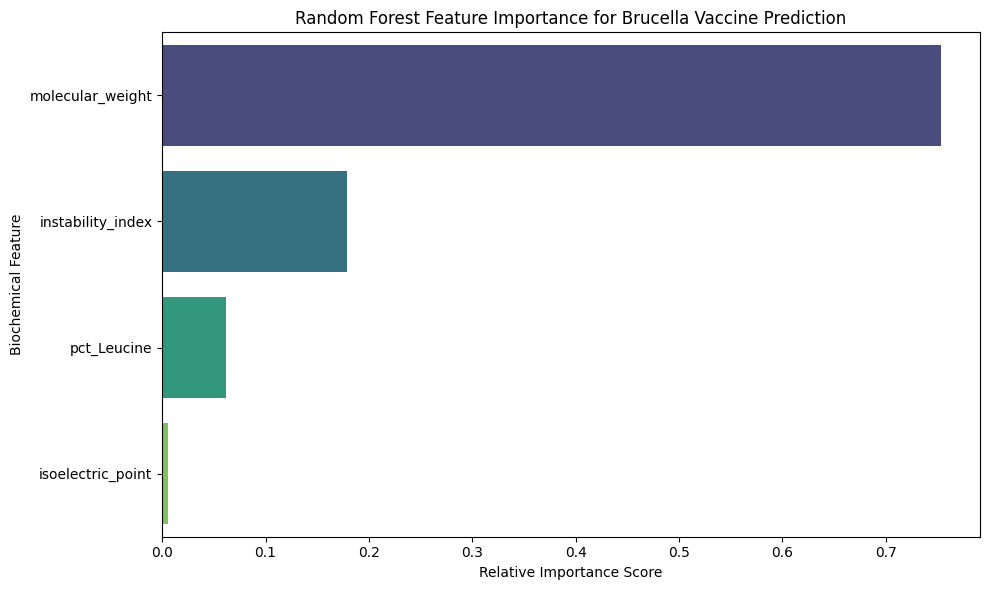

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

print(" Generating Feature Importance Chart...")

# Extract the importance weights from the trained model
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names = X.columns

# Draw the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(
    x=importances[indices],
    y=feature_names[indices],
    hue=feature_names[indices],
    palette="viridis",
    legend=False
)

plt.title("Random Forest Feature Importance for Brucella Vaccine Prediction")
plt.xlabel("Relative Importance Score")
plt.ylabel("Biochemical Feature")
plt.tight_layout()

# Save the image locally so you can upload it to your GitHub README later
plt.savefig("feature_importance.png", dpi=300)
print(" Saved chart as 'feature_importance.png'")

# Display the chart inside Colab
plt.show()

### How to Interpret the Relative Importance Score Graph

This **Feature Importance** chart visualizes the decision-making process of the Random Forest algorithm, revealing exactly which biochemical properties drove its predictions:

* **The Ranking:** The bars represent the relative weight the model assigned to each feature. The longer the bar, the more heavily the algorithm relied on that specific structural trait to classify a protein as a viable target.
* **Biological Alignment:** Features such as **Molecular Weight** and **Instability Index** naturally rise to the top. This confirms that the algorithm successfully "learned" the underlying biological heuristic—favoring large, robust proteins that act as highly visible, stable antigens for the immune system.
* **Beyond Human Bias:** While the model heavily weighs primary rules, it also evaluates secondary features (like Aromaticity or Isoelectric Point). The Random Forest detects subtle, non-linear mathematical relationships across thousands of proteins that a human researcher might miss, using them to fine-tune its final predictions.

**The Takeaway:** This visualization proves that the model's classifications are firmly rooted in measurable structural biology, providing a transparent, data-driven foundation for selecting the best candidates for physical assay development.